# Sandstone thin-section generation workflow

This notebook provides a simplified demonstration of the proposed thin-section generation workflow. It is intended to illustrate the main methodological steps used in the manuscript and does not include the full experimental dataset, complete digital-core data, or complete mineral particle library used in the study.

Main steps:
1. Read digital-core raw slices.
2. Build dissolution/cementation masks.
3. Segment mineral regions into independent particle instances.
4. Reconstruct one XPL image and one PPL image using particle texture mapping.
5. Apply simulation-based enhancement.
6. Save XPL, PPL, and single-channel label masks for semantic segmentation.

## 1. Import libraries and utility functions

In [ ]:
from pathlib import Path
import sys

import cv2
import numpy as np
import matplotlib.pyplot as plt

# If this notebook is placed in the same folder as tools_clean.py, this is enough.
# Otherwise, change PROJECT_DIR to the folder containing tools_clean.py.
PROJECT_DIR = Path(".").resolve()
sys.path.insert(0, str(PROJECT_DIR))

from tools import (
    read_raw_slice,
    build_diagenetic_masks,
    segment_mineral_particles,
    generateMasks,
    smooth_particle_masks,
    reconstruct_single_xpl_ppl,
    apply_simulation_enhancement,
    save_segmentation_sample,
)


## 2. Set paths and parameters

In [ ]:
# ---------------------------------------------------------------------
# Digital-core raw files
# ---------------------------------------------------------------------
# Main digital-core label file
label_raw_path = Path(r"example/3D_rock_data/C22_x250y250z1.raw")

# Feldspar dissolution / cementation file used to build masks
# If you do not use this file, set fdd_raw_path = None
fdd_raw_path = Path(r"example/3D_rock_data/FDD.raw")
# fdd_raw_path = None

# Raw volume shape in (z, y, x) order
raw_shape = (1, 250, 250)

# Slice index along z
slice_index = 0

# Output image size in (width, height). Use None if no resizing is needed.
resize_to = (1024, 1024)


# ---------------------------------------------------------------------
# Particle library paths
# Each mineral library should contain:
#     cross_1/  for XPL textures
#     single/   for PPL textures
# ---------------------------------------------------------------------
quartz_dir = Path(r"example/v2_keli_data/quartzData")
feldspar_dir = Path(r"example/v2_keli_data/feldsparData")
lithic_dir = Path(r"example/v2_keli_data/rockchipsData")

xpl_folder = "cross_1"
ppl_folder = "single"


# ---------------------------------------------------------------------
# Instance-ID offsets, following the original notebook
# quartz:   1 ~ 499
# feldspar: 500 ~ 799
# lithic:   >= 800
# ---------------------------------------------------------------------
num1 = 500
num2 = 800


# ---------------------------------------------------------------------
# Output dataset
# ---------------------------------------------------------------------
output_dir = Path("generated_dataset")
sample_name = f"sample_{slice_index:04d}"


## 3. Read digital-core slices

rock_slice unique values: [0 1 2 3]
rock_slice shape: (1024, 1024)
fdd_slice unique values: [0 1 2 3 4]


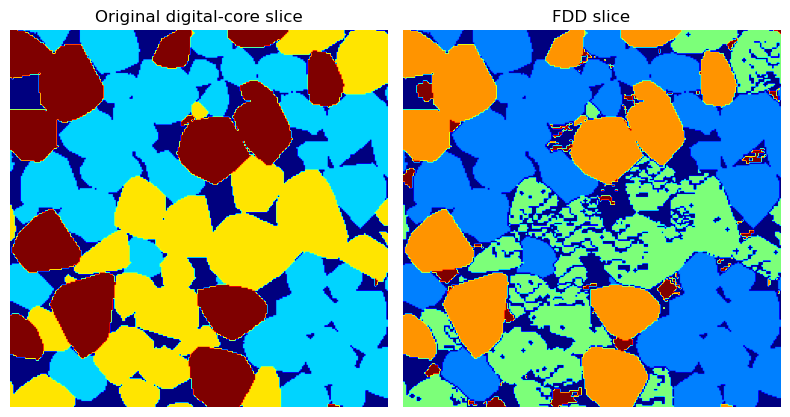

In [20]:
rock_slice = read_raw_slice(
    label_raw_path,
    shape=raw_shape,
    slice_index=slice_index,
    resize_to=resize_to,
)

if fdd_raw_path is not None:
    fdd_slice = read_raw_slice(
        fdd_raw_path,
        shape=raw_shape,
        slice_index=slice_index,
        resize_to=resize_to,
    )

    # Keep the same recoding logic used in the original notebook.
    # 4 is treated as background/clay in FDD, and 7 is treated as cementation.
    fdd_slice = fdd_slice.copy()
    fdd_slice[fdd_slice == 4] = 0
    fdd_slice[fdd_slice == 7] = 4
else:
    fdd_slice = None

print("rock_slice unique values:", np.unique(rock_slice))
print("rock_slice shape:", rock_slice.shape)

if fdd_slice is not None:
    print("fdd_slice unique values:", np.unique(fdd_slice))

plt.figure(figsize=(8, 5))
plt.subplot(1, 2, 1)
plt.imshow(rock_slice, cmap="jet")
plt.title("Original digital-core slice")
plt.axis("off")

if fdd_slice is not None:
    plt.subplot(1, 2, 2)
    plt.imshow(fdd_slice, cmap="jet")
    plt.title("FDD slice")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Build masks for simulation enhancement

rock_base unique values: [0 1 2 3]
cementation mask pixels: 20983
dissolution mask pixels: 62885


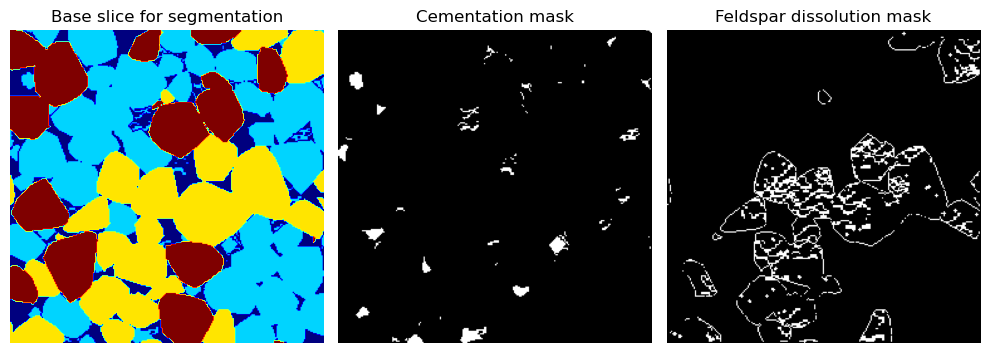

In [17]:
rock_base, mask_cem, mask_por1 = build_diagenetic_masks(
    rock_slice,
    fdd_slice=fdd_slice,
)

print("rock_base unique values:", np.unique(rock_base))
print("cementation mask pixels:", int(mask_cem.sum()))
print("dissolution mask pixels:", int(mask_por1.sum()))

plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(rock_base, cmap="jet")
plt.title("Base slice for segmentation")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_cem, cmap="gray")
plt.title("Cementation mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(mask_por1, cmap="gray")
plt.title("Feldspar dissolution mask")
plt.axis("off")

plt.tight_layout()
plt.show()


## 5. Segment mineral particles using watershed

Number of particle masks: 94
Instance IDs example: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


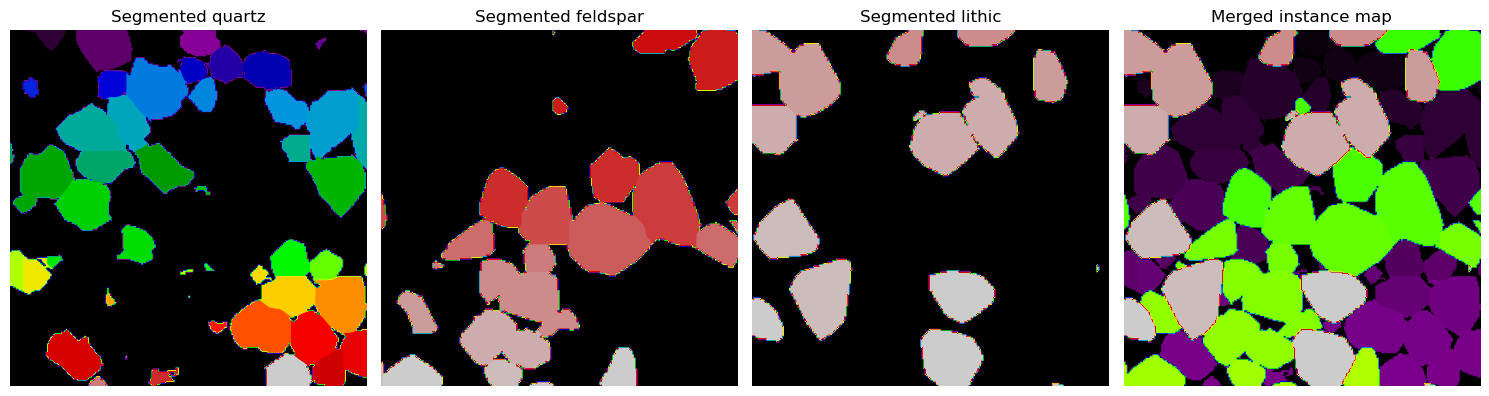

In [16]:
rock_slice_segmented, segmented_parts = segment_mineral_particles(
    rock_base,
    quartz_value=1,
    feldspar_value=2,
    lithic_value=3,
    num1=num1,
    num2=num2,
    sigma_quartz=13,
    sigma_feldspar=11,
    sigma_lithic=7,
)

particle_masks = generateMasks(rock_slice_segmented)

# Optional smoothing. Set perturb=True if you want random boundary perturbation.
particle_masks = smooth_particle_masks(
    particle_masks,
    kernel_size=5,
    blur_kernel=11,
    blur_sigma=5,
    perturb=False,
    max_offset=3,
)

print("Number of particle masks:", len(particle_masks))
print("Instance IDs example:", list(particle_masks.keys())[:10])

plt.figure(figsize=(15, 5))
plt.subplot(1, 4, 1)
plt.imshow(segmented_parts["quartz"], cmap="nipy_spectral")
plt.title("Segmented quartz")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(segmented_parts["feldspar"], cmap="nipy_spectral")
plt.title("Segmented feldspar")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(segmented_parts["lithic"], cmap="nipy_spectral")
plt.title("Segmented lithic")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(rock_slice_segmented, cmap="nipy_spectral")
plt.title("Merged instance map")
plt.axis("off")

plt.tight_layout()
plt.show()


## 6. Reconstruct one XPL image and one PPL image

XPL: (1024, 1024, 3) uint8
PPL: (1024, 1024, 3) uint8
Label mask: (1024, 1024) uint8 [0 1 2 3]


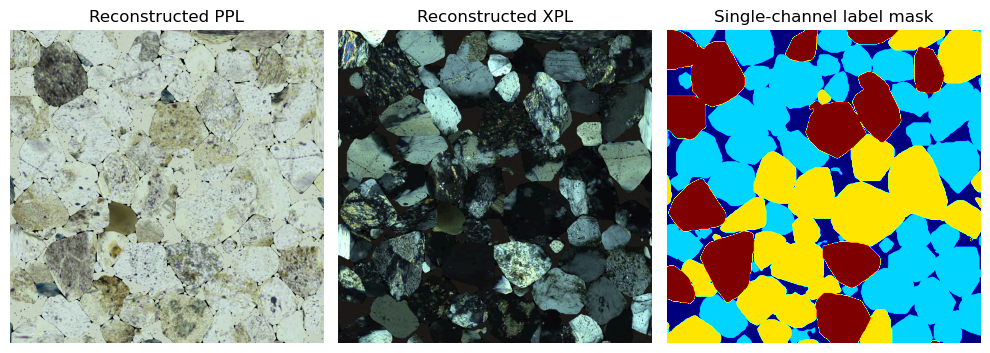

In [15]:
thin_xpl, thin_ppl, label_mask = reconstruct_single_xpl_ppl(
    rockSlice_segmented=rock_slice_segmented,
    particle_masks=particle_masks,
    quartz_dir=quartz_dir,
    feldspar_dir=feldspar_dir,
    lithic_dir=lithic_dir,
    num1=num1,
    num2=num2,
    xpl_folder=xpl_folder,
    ppl_folder=ppl_folder,
    width_tol=0.1,
    ratio_tol=0.1,
    temperature=0.5,
    pore_bg_color=(199, 220, 199),
)

print("XPL:", thin_xpl.shape, thin_xpl.dtype)
print("PPL:", thin_ppl.shape, thin_ppl.dtype)
print("Label mask:", label_mask.shape, label_mask.dtype, np.unique(label_mask))

plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
plt.imshow(thin_ppl)
plt.title("Reconstructed PPL")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(thin_xpl)
plt.title("Reconstructed XPL")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(label_mask, cmap="jet", vmin=0, vmax=3)
plt.title("Single-channel label mask")
plt.axis("off")

plt.tight_layout()
plt.show()


## 7. Apply simulation-based enhancement

Enhancement masks: ['dissolution_edges', 'clay_mask']


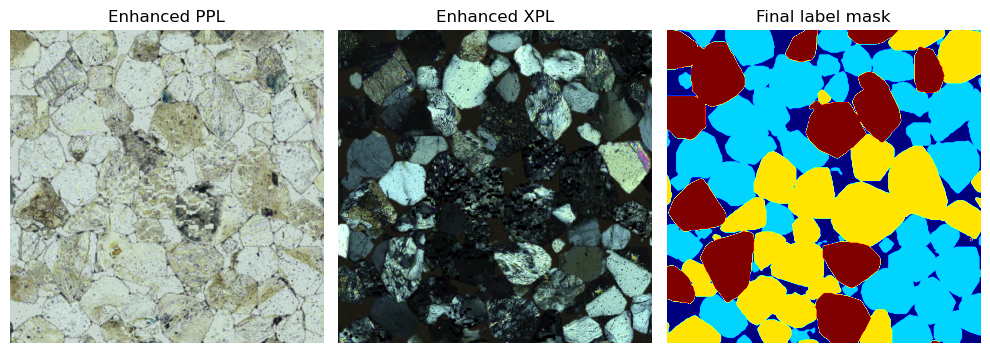

In [14]:
thin_xpl_enhanced, thin_ppl_enhanced, enhancement_masks = apply_simulation_enhancement(
    thin_xpl,
    thin_ppl,
    rockSlice_segmented=rock_slice_segmented,
    dissolution_mask=mask_por1.astype(bool),
    ppl_pore_color=(199, 220, 199),
    add_clay=True,
)

print("Enhancement masks:", list(enhancement_masks.keys()))

plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
plt.imshow(thin_ppl_enhanced)
plt.title("Enhanced PPL")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(thin_xpl_enhanced)
plt.title("Enhanced XPL")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(label_mask, cmap="jet", vmin=0, vmax=3)
plt.title("Final label mask")
plt.axis("off")

plt.tight_layout()
plt.show()


## 8. Compare images before and after enhancement

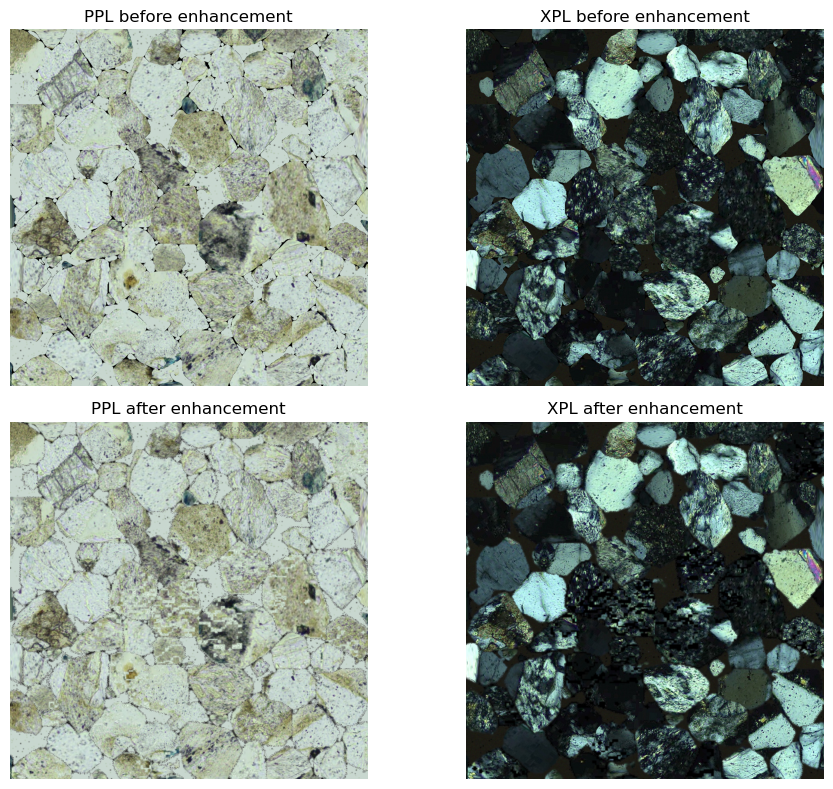

In [12]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(thin_ppl)
plt.title("PPL before enhancement")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(thin_xpl)
plt.title("XPL before enhancement")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(thin_ppl_enhanced)
plt.title("PPL after enhancement")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(thin_xpl_enhanced)
plt.title("XPL after enhancement")
plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
save_segmentation_sample(
    output_dir=output_dir,
    sample_name=sample_name,
    xpl_image=thin_xpl_enhanced,
    ppl_image=thin_ppl_enhanced,
    label_mask=label_mask,
)

print("Saved:")
print(output_dir / "xpl" / f"{sample_name}.png")
print(output_dir / "ppl" / f"{sample_name}.png")
print(output_dir / "labels" / f"{sample_name}.png")